In [1]:
# CODEALPHA MACHINE LEARNING INTERNSHIP
# TASK 2: DISEASE PREDICTION FROM MEDICAL DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
        confusion_matrix,
            classification_report
            )

In [2]:
# PROJECT HEADER


print("DISEASE PREDICTION FROM MEDICAL DATA")
print("CodeAlpha Machine Learning Internship Project")


# LOAD DATASET


print("\nLoading Breast Cancer Dataset...")

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("\nDataset Loaded Successfully!")
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

DISEASE PREDICTION FROM MEDICAL DATA
CodeAlpha Machine Learning Internship Project

Loading Breast Cancer Dataset...

Dataset Loaded Successfully!
Features Shape : (569, 30)
Target Shape   : (569,)


In [3]:
# DATASET INFORMATION


print("\nFirst Five Rows:")
print(X.head())

print("\nDataset Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum().sum())


First Five Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimet

In [4]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))



Training Samples : 455
Testing Samples  : 114


In [5]:
# FEATURE SCALING


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# MODEL 1 - LOGISTIC REGRESSION


print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:",
      round(lr_accuracy * 100, 2), "%")


# MODEL 2 - RANDOM FOREST


print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")



Training Logistic Regression...
Logistic Regression Accuracy: 97.37 %

Training Random Forest...
Random Forest Accuracy: 96.49 %


In [7]:
# MODEL 3 - SUPPORT VECTOR MACHINE


print("\nTraining Support Vector Machine...")

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:",
      round(svm_accuracy * 100, 2), "%")


Training Support Vector Machine...
SVM Accuracy: 98.25 %


In [8]:
# ACCURACY COMPARISON


accuracy_scores = {
    "Logistic Regression": lr_accuracy,
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy
}

best_model_name = max(
    accuracy_scores,
    key=accuracy_scores.get
)

print("MODEL COMPARISON")

for model, score in accuracy_scores.items():
    print(f"{model:25} : {score*100:.2f}%")

print("\nBest Model:", best_model_name)

MODEL COMPARISON
Logistic Regression       : 97.37%
Random Forest             : 96.49%
SVM                       : 98.25%

Best Model: SVM


In [9]:
# BEST MODEL SELECTION


if best_model_name == "Logistic Regression":
    best_model = lr_model
    best_prediction = lr_pred

elif best_model_name == "Random Forest":
    best_model = rf_model
    best_prediction = rf_pred

else:
    best_model = svm_model
    best_prediction = svm_pred

In [10]:
# CONFUSION MATRIX

print("\nConfusion Matrix:\n")

cm = confusion_matrix(y_test, best_prediction)

print(cm)


# CLASSIFICATION REPORT

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best_prediction
    )
)



Confusion Matrix:

[[41  2]
 [ 0 71]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [11]:
# FEATURE IMPORTANCE


print("\nTop Important Features:")

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))


Top Important Features:
                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


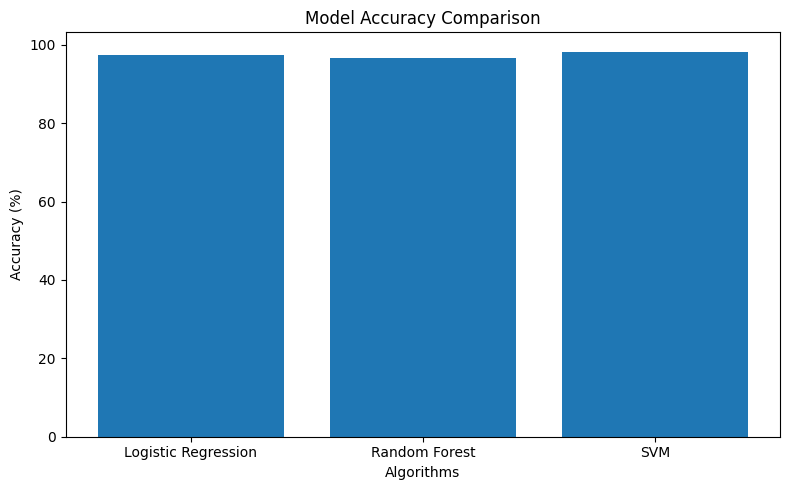

In [12]:
# GRAPH 1 - ACCURACY COMPARISON


plt.figure(figsize=(8, 5))

models = list(accuracy_scores.keys())
scores = [score * 100 for score in accuracy_scores.values()]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithms")

plt.tight_layout()
plt.show()

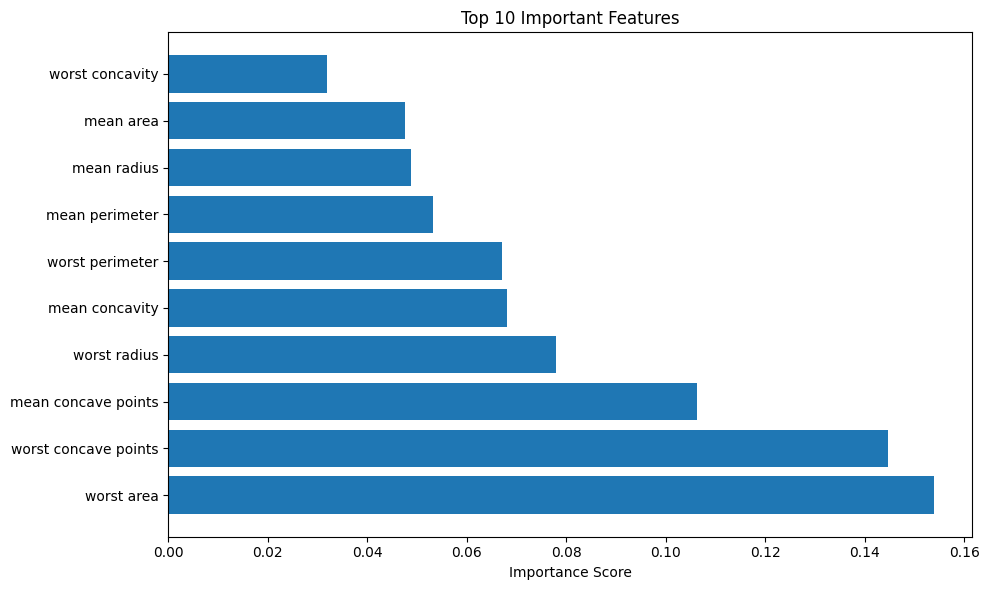

In [19]:
# GRAPH 2 - FEATURE IMPORTANCE

top_features = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()


In [20]:
# SAMPLE PREDICTION


print("SAMPLE PATIENT PREDICTION")

sample_patient = X.iloc[0].values.reshape(1, -1)

if best_model_name == "Random Forest":
    prediction = best_model.predict(sample_patient)

else:
    sample_patient = scaler.transform(sample_patient)
    prediction = best_model.predict(sample_patient)

if prediction[0] == 1:
    print("\nPrediction Result:")
    print("BENIGN (No Cancer Detected)")
else:
    print("\nPrediction Result:")
    print("MALIGNANT (Cancer Detected)")


SAMPLE PATIENT PREDICTION

Prediction Result:
MALIGNANT (Cancer Detected)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
# SAVE MODEL RESULTS

results = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": scores
})

results.to_csv(
    "model_results.csv",
    index=False
)

print("\nResults saved to model_results.csv")

print("\nProject Execution Completed Successfully!")


Results saved to model_results.csv

Project Execution Completed Successfully!
